# dala-dock: why vancomycin resistance happens

We dock small peptide **candidates** into the antibiotic **vancomycin** and watch, stage by stage,
why the native **D-Ala-D-Ala** cell-wall terminus binds tightly while the resistant
**D-Ala-D-Lac** variant does not.

Runs anywhere: **Vina** on a laptop (no GPU), **AutoDock-GPU** automatically on a GPU cluster.

**How to use:** run each cell top to bottom. Every stage prints what it did and shows a 3D picture.

In [1]:
# --- setup: make the daladock package importable and set a work directory ---
import sys, os, pathlib
for _p in os.environ.get('PYTHONPATH', '').split(os.pathsep):
    while _p and _p in sys.path:
        sys.path.remove(_p)

REPO = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(REPO / 'src'))
WORK = REPO / 'work'; WORK.mkdir(exist_ok=True); os.chdir(WORK)
DATA = REPO / 'data'

import pandas as pd
import matplotlib.pyplot as plt
from daladock import prep_receptor, box, prep_ligand, dock, analyze, viz
print('working dir:', WORK)
print('docking engine that will be used:', dock.detect_engine())

working dir: /Users/bahlow/Desktop/INTERNSHIP/Bootcamp/dala-dock/work
  engine=auto -> vina  (no GPU/AutoDock-GPU found; using Vina)
docking engine that will be used: vina


## Stage 1 - Prepare the receptor (vancomycin)

Fetch **1FVM** (vancomycin + D-Ala-D-Ala) and keep vancomycin (chain A). It's a glycopeptide with
non-standard residues, so `prepare_receptor` auto-selects **OpenBabel**.

In [2]:
rec = prep_receptor.prepare_receptor('1FVM', out='vancomycin', keep_chains=['A'],
                                     extract_ref=False)
viz.view_structure(rec['pdbqt'])   # vancomycin in 3D

  standard-residue fraction=0.14 -> method=obabel
  wrote vancomycin.pdbqt  types=A C Cl HD N NA OA  atoms=96


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Stage 2 - Define the search box

AutoDock does not find pockets - we tell it where to look. Center the box on the **known bound
D-Ala-D-Ala** (`data/dala_ref.pdb`). The magenta box is the search region.

In [5]:
b = box.define_box(rec['pdbqt'], ref=str(DATA / 'dala_ref.pdb'), detect='blind')  #ref/fpocket/blind
viz.view_box(rec['pdbqt'], b['center'], b['size'])

  box from blind (whole receptor): center=[0.09, 2.726, 25.002] size=[21.0, 19.0, 24.5]


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Stage 3 - Prepare the candidates

The panel in `data/candidates.csv`: native terminus, the two real resistance variants
(D-Ala-D-Lac, D-Ala-D-Ser), and controls. Each SMILES is built to 3D and written as PDBQT.

In [7]:
cands = pd.read_csv(DATA / 'candidates.csv')
display(cands)
ligands = {}
for _, row in cands.iterrows():
    ligands[row['name']] = prep_ligand.prepare_ligand(row['smiles'], out=row['name'])
viz.view_ligand(ligands['D-Ala-D-Ala']['pdbqt'])   # peek at one candidate

,name,smiles,note
0,D-Ala-D-Ala,CC(=O)N[C@H](C)C(=O)N[C@H](C)C(=O)O,native cell-wall terminus (drug-SENSITIVE)
1,D-Ala-D-Lac,CC(=O)N[C@H](C)C(=O)O[C@H](C)C(=O)O,VanA/VanB RESISTANT (amide->ester)
2,D-Ala-D-Ser,CC(=O)N[C@H](C)C(=O)N[C@H](CO)C(=O)O,VanC RESISTANT (bulkier -CH2OH)
3,D-Ala-Gly,CC(=O)N[C@H](C)C(=O)NCC(=O)O,control: terminal methyl removed
4,D-Ala-D-Val,CC(=O)N[C@H](C)C(=O)N[C@H](C(C)C)C(=O)O,control: bulkier terminal side chain
5,L-Ala-D-Ala,CC(=O)N[C@@H](C)C(=O)N[C@H](C)C(=O)O,negative control: wrong stereochemistry


  D-Ala-D-Ala: 28 atoms, 0 torsions, types=C HD N OA
  D-Ala-D-Lac: 27 atoms, 0 torsions, types=C HD N OA
  D-Ala-D-Ser: 29 atoms, 0 torsions, types=C HD N OA
  D-Ala-Gly: 25 atoms, 0 torsions, types=C HD N OA
  D-Ala-D-Val: 34 atoms, 0 torsions, types=C HD N OA
  L-Ala-D-Ala: 28 atoms, 0 torsions, types=C HD N OA


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Stage 4 - Dock every candidate

`engine='auto'` uses Vina on a laptop or AutoDock-GPU on a GPU node. Each run produces several
**poses** (tries) - we keep them all so we can inspect them next.

In [8]:
results = {}
for name, lig in ligands.items():
    print(name)
    results[name] = dock.dock(rec['pdbqt'], lig['pdbqt'], b['center'], b['size'],
                              engine='auto', out=name, n_poses=10)

D-Ala-D-Ala
  engine=auto -> vina  (no GPU/AutoDock-GPU found; using Vina)
  [vina] best affinity = -4.96 kcal/mol  (10 poses)
D-Ala-D-Lac
  engine=auto -> vina  (no GPU/AutoDock-GPU found; using Vina)
  [vina] best affinity = -4.63 kcal/mol  (10 poses)
D-Ala-D-Ser
  engine=auto -> vina  (no GPU/AutoDock-GPU found; using Vina)
  [vina] best affinity = -4.57 kcal/mol  (10 poses)
D-Ala-Gly
  engine=auto -> vina  (no GPU/AutoDock-GPU found; using Vina)
  [vina] best affinity = -4.57 kcal/mol  (10 poses)
D-Ala-D-Val
  engine=auto -> vina  (no GPU/AutoDock-GPU found; using Vina)
  [vina] best affinity = -4.99 kcal/mol  (10 poses)
L-Ala-D-Ala
  engine=auto -> vina  (no GPU/AutoDock-GPU found; using Vina)
  [vina] best affinity = -4.73 kcal/mol  (10 poses)


## Stage 4b - Look inside one candidate's poses

Docking returns many **poses** (attempts), each with an energy. Let's open up native **D-Ala-D-Ala**.
Per pose:
- **affinity** - predicted binding energy (more negative = better)
- **rmsd_to_best** - how far this pose sits from the best pose (Angstrom)
- **cluster / cluster_size** - poses within ~2 A are grouped; a big low-energy cluster = confident answer.

In [9]:
candidate = 'D-Ala-D-Ala'
r = results[candidate]
poses_tbl = analyze.cluster_poses(r['poses'], r['scores'])
print(f"{candidate}: {len(r['scores'])} poses, engine = {r['engine']}")
display(poses_tbl)

D-Ala-D-Ala: 10 poses, engine = vina


,pose,affinity_kcal_mol,rmsd_to_best_A,cluster,cluster_size
0,1,-4.96,0.00,1,1
1,2,-4.74,2.78,2,1
2,3,-4.02,5.56,3,1
3,4,-3.93,4.63,4,1
4,5,-3.84,2.08,5,1
5,6,-3.78,5.91,6,1
6,7,-3.52,5.60,7,1
7,8,-3.43,5.29,8,1
8,9,-3.29,5.18,9,1
9,10,-3.28,5.25,10,1


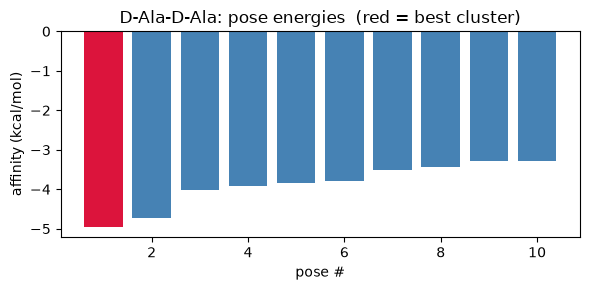

In [10]:
plt.figure(figsize=(6, 3))
colors = ['crimson' if c == 1 else 'steelblue' for c in poses_tbl['cluster']]
plt.bar(poses_tbl['pose'], poses_tbl['affinity_kcal_mol'], color=colors)
plt.xlabel('pose #'); plt.ylabel('affinity (kcal/mol)')
plt.title(f'{candidate}: pose energies  (red = best cluster)')
plt.tight_layout(); plt.show()

### All 10 poses overlaid
Each pose a different color. Good poses sit in the cleft; bad (high-energy) ones drift into solvent.

In [11]:
viz.view_poses(rec['pdbqt'], r['poses'], max_poses=10)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Best pose vs. a bad pose
First = pose 1 (lowest energy, in the pocket). Second = worst-scoring pose (drifted away).

In [12]:
best_pose = int(poses_tbl.iloc[0]['pose'])
viz.view_pose_n(rec['pdbqt'], r['poses'], best_pose,
                label=f"pose {best_pose}: {r['scores'][best_pose-1]:.2f} kcal/mol (best)")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [13]:
worst_pose = int(poses_tbl.sort_values('affinity_kcal_mol').iloc[-1]['pose'])
viz.view_pose_n(rec['pdbqt'], r['poses'], worst_pose,
                label=f"pose {worst_pose}: {r['scores'][worst_pose-1]:.2f} kcal/mol (worst)")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Step through every pose (interactive)
Drag the slider to view each pose with its energy. (Interactive only in a live kernel.)

In [14]:
import ipywidgets as widgets
from IPython.display import display

def show_pose(pose=1):
    aff = r['scores'][pose - 1]
    display(viz.view_pose_n(rec['pdbqt'], r['poses'], pose,
                            label=f'pose {pose}:  {aff:.2f} kcal/mol'))

widgets.interact(show_pose, pose=widgets.IntSlider(min=1, max=len(r['scores']), value=1));

interactive(children=(IntSlider(value=1, description='pose', max=10, min=1), Output()), _dom_classes=('widget-…

## Stage 5 - Leaderboard + best pose

Ranked by predicted binding (more negative = tighter). Expect native **D-Ala-D-Ala** on top and
the resistant variants weaker - the molecular basis of vancomycin resistance.

In [15]:
board = analyze.leaderboard(results, csv='leaderboard.csv')
display(board)
best = board.iloc[0]['ligand']
print('best binder:', best)
viz.view_complex(rec['pdbqt'], results[best]['poses'])   # vancomycin + top pose

  wrote leaderboard.csv


,ligand,best_score_kcal_mol,engine,n_poses,mean_top3
rank,,,,,
1,D-Ala-D-Val,-4.987,vina,10,-4.66
2,D-Ala-D-Ala,-4.955,vina,10,-4.57
3,L-Ala-D-Ala,-4.726,vina,10,-4.44
4,D-Ala-D-Lac,-4.632,vina,10,-4.39
5,D-Ala-D-Ser,-4.569,vina,10,-4.41
6,D-Ala-Gly,-4.569,vina,10,-4.36


best binder: D-Ala-D-Val


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## What to notice (the critical-thinking part)

- **Poses vs. answer:** docking tries many poses; the 'answer' is the lowest-energy one, trusted more
  when many poses cluster there (Stage 4b).
- **Direction vs magnitude:** docking gets the *ordering* right (native tighter) but *underestimates*
  the gap. Real vancomycin binds D-Ala-D-Ala ~1000x tighter than D-Ala-D-Lac. Trust trends, not exact kcal/mol.
- **Scores differ by engine:** Vina vs AutoDock-GPU use different scoring - compare rankings within one engine.
- **Validate first:** on a target with a known ligand, redock it and confirm <~2 A before trusting new scores.

### Try your own
Edit `data/candidates.csv` and re-run Stages 3-5. Different target? Give `prepare_receptor()` another PDB id.